## Lab4-Regression-using-PyTorch


### Objective
Understand how to implement a regression model using PyTorch

### Theory 
Regression is a supervised learning technique used to predict continuous values based on input features.
we use PyTorch's automatic differentiation system (autograd)

Key Concepts Used:
Tensors: Multi-dimensional arrays used for computation
nn.Module: Base class for all neural network models in PyTorch

nn.Parameter: Trainable model parameters

Loss Function (L1Loss): Measures prediction error using Mean Absolute Error

Optimizer (SGD): Updates model parameters using gradient descent

Training Loop: Iterative process of learning from data

### 1. Using Dataset 1

In [77]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [78]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [79]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [80]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [81]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [82]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

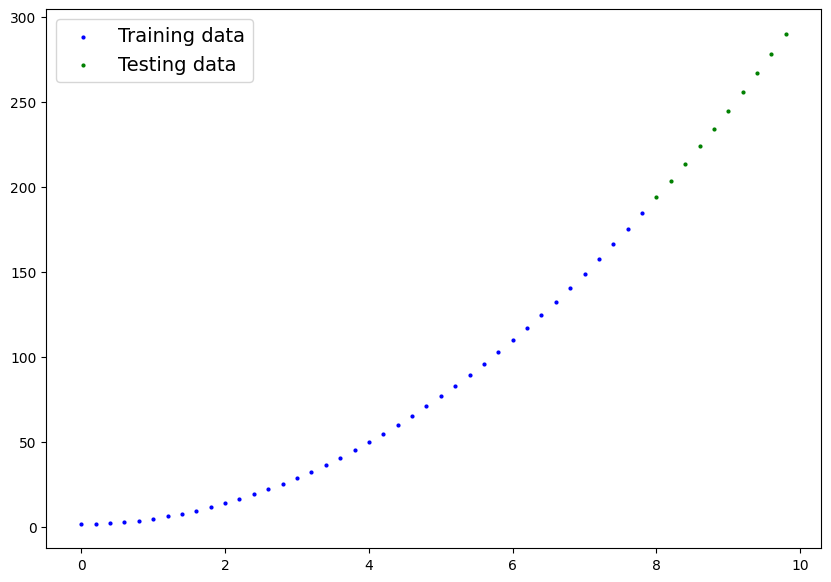

In [83]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation:
These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [84]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [85]:
model_0 = QuadraticRegressionModel()

In [86]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [87]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Predictions are inaccurate initially

Red scatter plot does not match real data

In [88]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


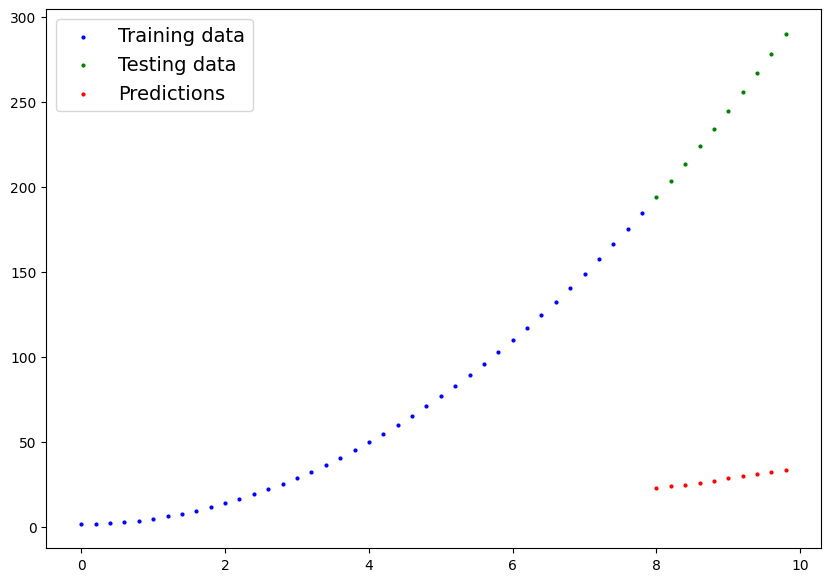

In [89]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [90]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [91]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967567443847656 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157401084899902 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925447940826416 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725956559181213 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113344192505 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148273706436157 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227550506591797 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

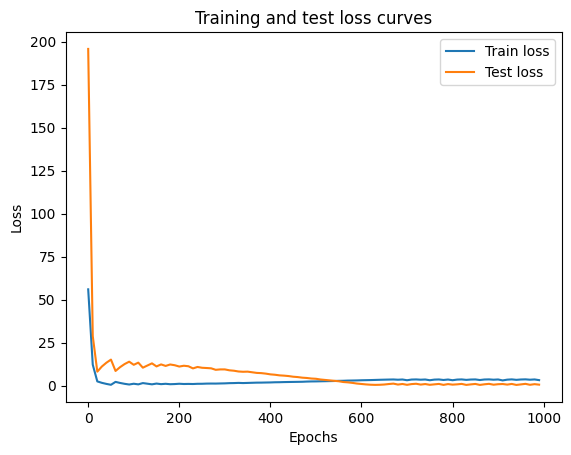

In [92]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

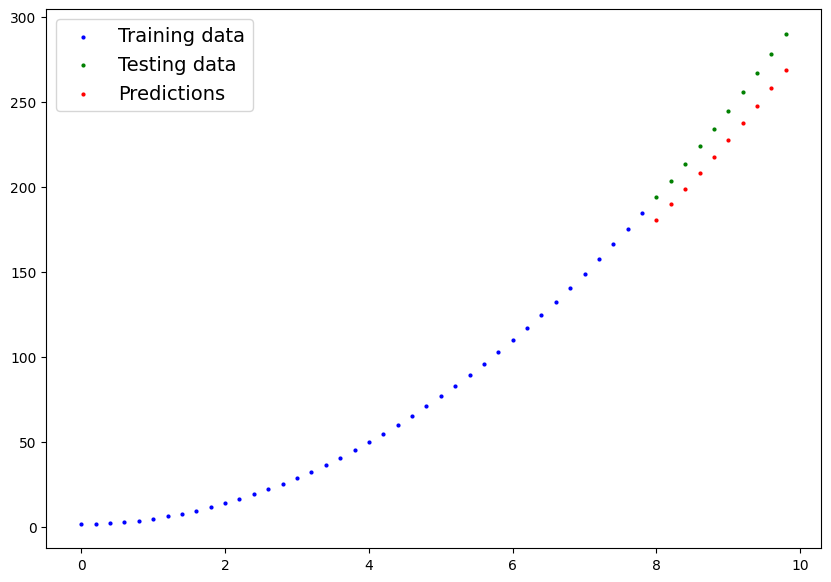

In [93]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Red points (predictions) align closely with actual data
Indicates successful learning of quadratic relationship

### Using Dataset 2

In [94]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [95]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [96]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [97]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [98]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [99]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

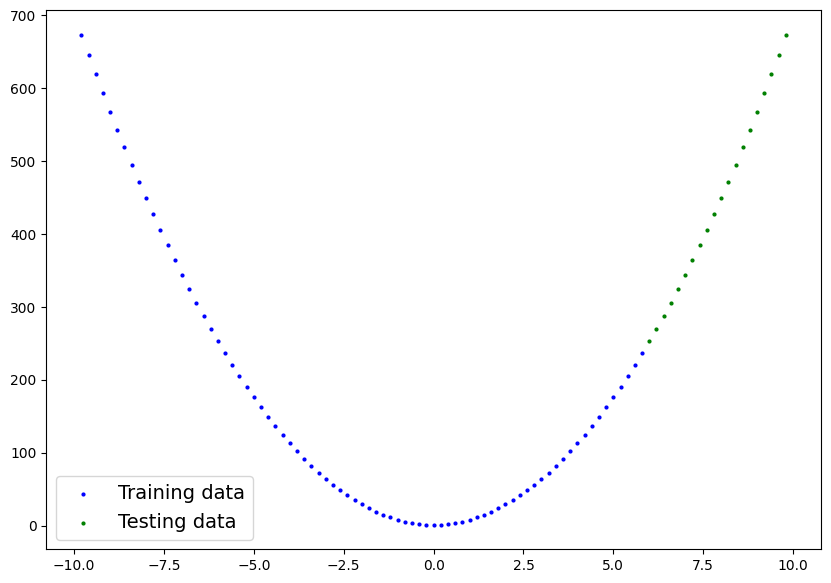

In [100]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation:
These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [101]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [102]:
model_0 = QuadraticRegressionModel()

In [103]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [104]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789]])

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Predictions are inaccurate initially

Red scatter plot does not match real data

In [105]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789],
        [17.6340],
        [18.6159],
        [19.6248],
        [20.6606],
        [21.7234],
        [22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


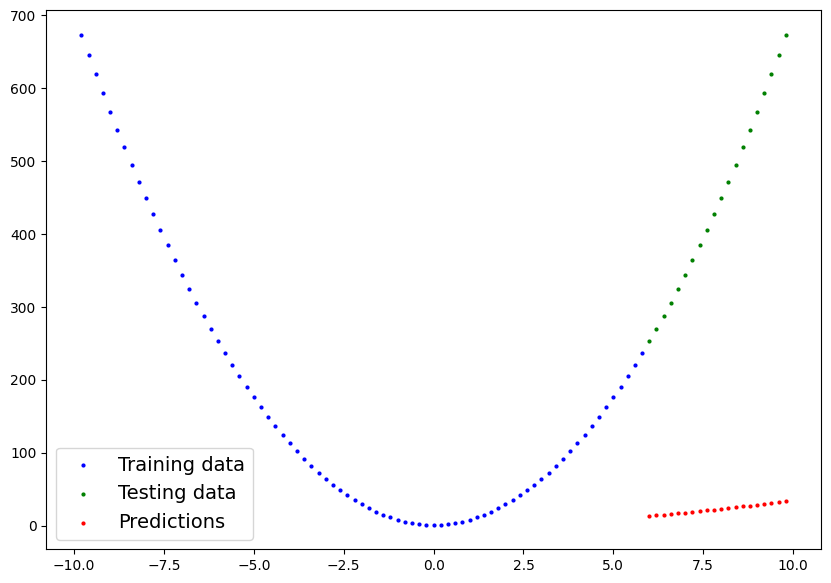

In [106]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [107]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [108]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.2732391357422 | MAE Test Loss: 408.80780029296875 
Epoch: 10 | MAE Train Loss: 104.26924896240234 | MAE Test Loss: 252.2126007080078 
Epoch: 20 | MAE Train Loss: 42.265235900878906 | MAE Test Loss: 95.61736297607422 
Epoch: 30 | MAE Train Loss: 2.1109044551849365 | MAE Test Loss: 6.325655937194824 
Epoch: 40 | MAE Train Loss: 1.2364041805267334 | MAE Test Loss: 8.994148254394531 
Epoch: 50 | MAE Train Loss: 1.0613059997558594 | MAE Test Loss: 9.811983108520508 
Epoch: 60 | MAE Train Loss: 1.1207306385040283 | MAE Test Loss: 10.009750366210938 
Epoch: 70 | MAE Train Loss: 0.8819621801376343 | MAE Test Loss: 10.844253540039062 
Epoch: 80 | MAE Train Loss: 0.9476220011711121 | MAE Test Loss: 10.903587341308594 
Epoch: 90 | MAE Train Loss: 1.473946452140808 | MAE Test Loss: 9.81262493133545 
Epoch: 100 | MAE Train Loss: 1.0053094625473022 | MAE Test Loss: 11.123434066772461 
Epoch: 110 | MAE Train Loss: 0.629422664642334 | MAE Test Loss: 12.171686172485352 
E

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

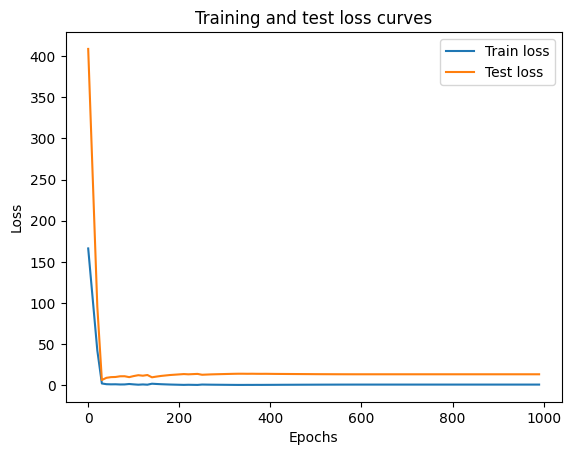

In [109]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

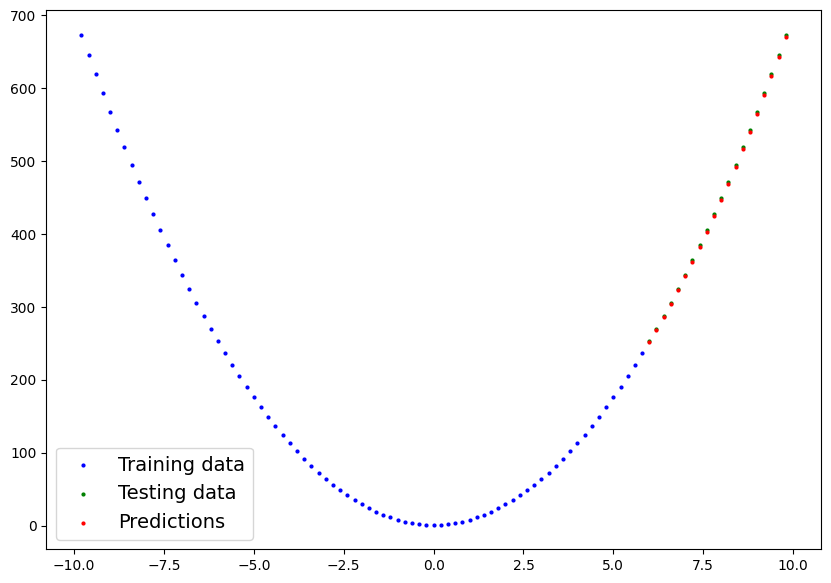

In [110]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Red points (predictions) align closely with actual data
Indicates successful learning of quadratic relationship

### Using Dataset 3

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'linear-regression-data1.csv')
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

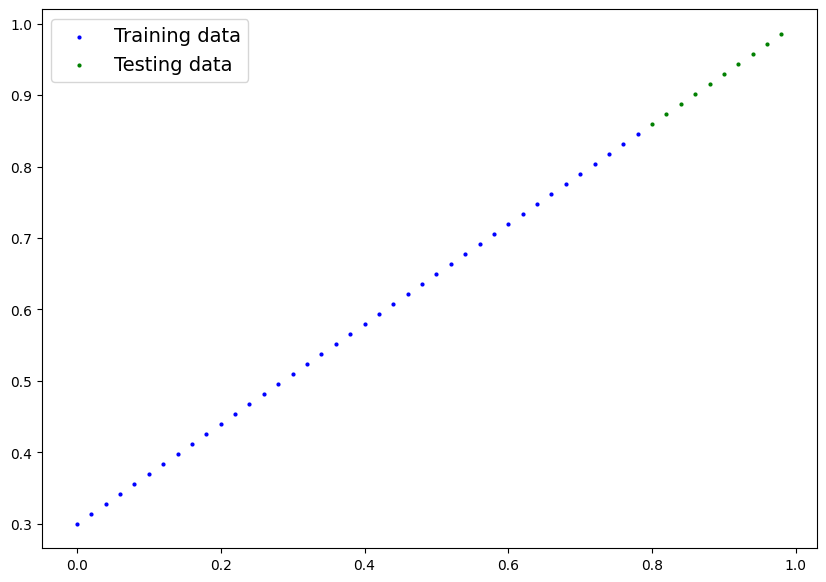

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a linear regression model:
y = wx + b

This model is suitable because the dataset shows a straight-line relationship between input and output variables.

In [ ]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.w = nn.Parameter(torch.randn(1, dtype=torch.float))
        self.b = nn.Parameter(torch.randn(1, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w * x + self.b

model_0 = LinearRegressionModel()

In [ ]:
print(model_0.w.dtype)
print(model_0.b.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[0.4179],
        [0.4226],
        [0.4273],
        [0.4320],
        [0.4367]])

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.4179],
        [0.4226],
        [0.4273],
        [0.4320],
        [0.4367],
        [0.4413],
        [0.4460],
        [0.4507],
        [0.4554],
        [0.4601]])


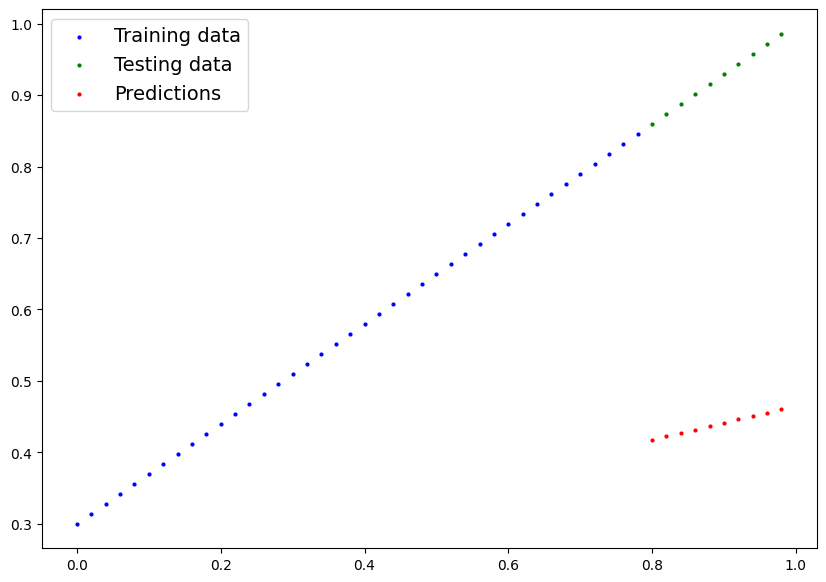

In [ ]:
plot_predictions(predictions=y_preds)

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Initial predictions are untrained and do not align well with the actual data distribution.

### Loss Function Selection

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.25122663378715515 | MAE Test Loss: 0.47052446007728577 
Epoch: 10 | MAE Train Loss: 0.14193940162658691 | MAE Test Loss: 0.34090352058410645 
Epoch: 20 | MAE Train Loss: 0.09095562994480133 | MAE Test Loss: 0.2517372965812683 
Epoch: 30 | MAE Train Loss: 0.07409851998090744 | MAE Test Loss: 0.20021207630634308 
Epoch: 40 | MAE Train Loss: 0.06757690757513046 | MAE Test Loss: 0.17111757397651672 
Epoch: 50 | MAE Train Loss: 0.06348922103643417 | MAE Test Loss: 0.15400443971157074 
Epoch: 60 | MAE Train Loss: 0.05999922752380371 | MAE Test Loss: 0.14298437535762787 
Epoch: 70 | MAE Train Loss: 0.05650923401117325 | MAE Test Loss: 0.1319642961025238 
Epoch: 80 | MAE Train Loss: 0.05305762216448784 | MAE Test Loss: 0.12300487607717514 
Epoch: 90 | MAE Train Loss: 0.04962731525301933 | MAE Test Loss: 0.11541922390460968 
Epoch: 100 | MAE Train Loss: 0.04619281366467476 | MAE Test Loss: 0.10714666545391083 
Epoch: 110 | MAE Train Loss: 0.04275400564074516 | MAE T

Output:

Model gradually learns the linear relationship between input and output variables by adjusting slope and intercept.

Loss Curve Visualization

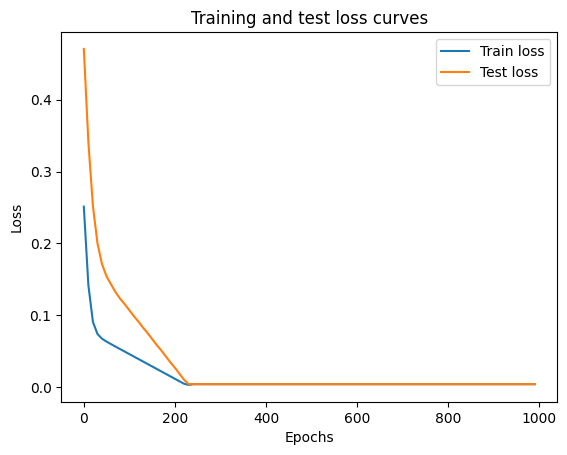

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

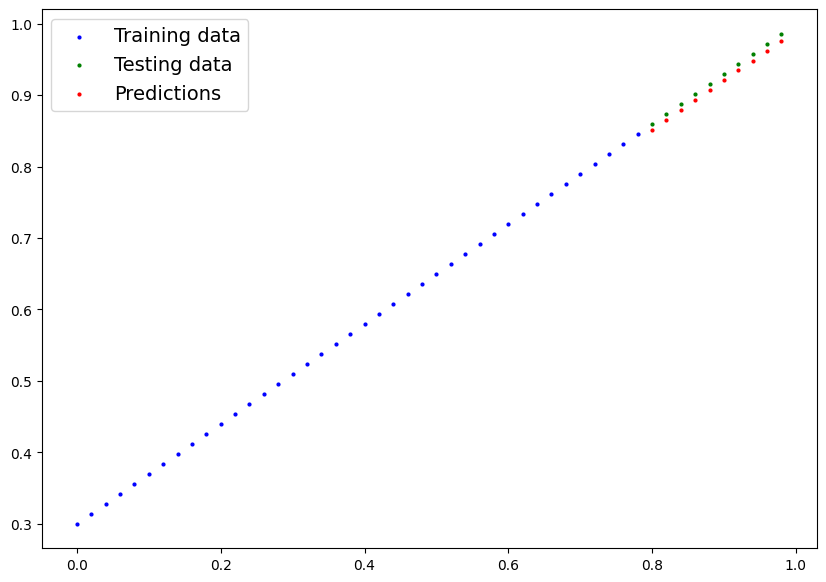

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Red points (predictions) align closely with actual data.
Indicates successful learning of the linear relationship between variables.

### Discussion

We did an experiment where we used PyTorch to see how input and output variables are related. We took the dataset and turned it into something the computer could understand then we split it into two parts: one for training and one for testing. When we looked at the data it was clear that it followed a line so we knew a simple linear model would work.

We made a model that could learn two things: a weight and a bias. At first the model made guesses because it started with random numbers.. As it trained it used a way to measure mistakes called Mean Absolute Error and a way to get better called Stochastic Gradient Descent.

As the model got training it made fewer mistakes and this was true for both the training and testing parts. This showed that the linear regression model was really learning. Finally when we looked at the set of predictions we saw that they matched the real data very closely which meant that the linear regression model had figured out the relationship between the variables in the dataset. The linear regression model was good, at predicting the output variables based on the input variables. This was because the linear regression model had learned from the dataset.

### Conclusion


This experiment showed that we can use PyTorch to do linear regression. We got the data ready split it up and used it to teach a linear model.

The loss values went down as we trained the model, which means the linear regression model learned how the variables are related. The predictions we made were very close to the data points, which means the linear regression model worked well.

Overall the results show that linear regression works well for data that follows a line and PyTorch is a good tool for making and training linear regression models. We learned that linear regression is a choice for datasets, with a straight-line pattern and PyTorch makes it easy to build and train linear regression models.